# EDA — Polymarket Prediction Markets (Q3 2025 – Q2 2026)

**Fase 3 del TFI — Análisis Exploratorio de Datos**

Dataset: 967 mercados binarios resueltos con ≥ 3 puntos de precio en la ventana de 7 días.

### Estructura del notebook
1. Setup y carga de datos
2. Análisis de categorías (investigación del grupo `Other`)
3. Distribución del target (YES/NO) por categoría
4. Análisis de features de precio
5. Análisis temporal
6. Features adicionales: `n_puntos_precio`, `log_volumen_total`, duración
7. Clustering exploratorio (k-means)
8. Resumen de hallazgos

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
from src.data.download import infer_category_coarse, get_start_dt, parse_dt, MIN_PRICE_POINTS

# ── Rutas ──────────────────────────────────────────────────────────────────
RAW_DIR     = Path('../data/raw')
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Estilo global ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150,
                     'figure.figsize': (10, 5)})

PALETTE = {0: '#4C72B0', 1: '#DD8452'}  # azul=NO, naranja=YES
print('Setup OK')

Setup OK


## 1. Carga de datos

Construimos el DataFrame de features a partir de los archivos crudos en `data/raw/`.

In [2]:
def build_price_features(history: list, start_ts: int) -> dict | None:
    """Calcula features de precio a partir de la serie histórica cruda."""
    history = sorted(history, key=lambda x: x['t'])
    n_pts = len(history)
    if n_pts < MIN_PRICE_POINTS:
        return None

    prices = [h['p'] for h in history]

    # Mapeo timestamp → día (1-7)
    day_prices = {}
    for h in history:
        d = min(int((h['t'] - start_ts) / 86400) + 1, 7)
        day_prices[d] = h['p']

    row = {f'precio_dia_{d}': day_prices.get(d, np.nan) for d in range(1, 8)}
    row['precio_inicio']  = prices[0]
    row['precio_fin']     = prices[-1]
    row['precio_media']   = float(np.mean(prices))
    row['precio_mediana'] = float(np.median(prices))
    row['precio_std']     = float(np.std(prices, ddof=1)) if n_pts > 1 else 0.0
    row['precio_rango']   = float(max(prices) - min(prices))

    t_norm = np.arange(n_pts, dtype=float)
    row['precio_tendencia'] = float(np.polyfit(t_norm, prices, 1)[0]) if n_pts >= 2 else 0.0

    if n_pts >= 3:
        safe = [(prices[i], prices[i-1]) for i in range(1, n_pts)
                if prices[i] > 0 and prices[i-1] > 0]
        log_rets = [np.log(a/b) for a, b in safe]
        row['volatilidad_retornos'] = float(np.std(log_rets, ddof=1)) if len(log_rets) >= 2 else 0.0
    else:
        row['volatilidad_retornos'] = 0.0

    row['n_puntos_precio'] = n_pts
    return row


def load_dataset() -> pd.DataFrame:
    rows = []
    for mfile in sorted(RAW_DIR.glob('markets/*.json')):
        cid   = mfile.stem
        pfile = RAW_DIR / f'prices/{cid}.json'
        if not pfile.exists():
            continue
        market     = json.load(open(mfile, encoding='utf-8'))
        price_data = json.load(open(pfile, encoding='utf-8'))

        pf = build_price_features(price_data.get('history', []),
                                   price_data.get('start_ts', 0))
        if pf is None:
            continue

        try:
            start_dt  = get_start_dt(market)
            closed_dt = parse_dt(market['closedTime'])
            duration  = (closed_dt - start_dt).days
        except Exception:
            continue

        raw_op  = market.get('outcomePrices', '[]')
        op      = json.loads(raw_op) if isinstance(raw_op, str) else raw_op
        outcome = 1 if float(op[0]) == 1.0 else 0

        events = market.get('events') or []
        ticker = events[0].get('ticker', '') if events else ''

        rows.append({
            'condition_id'     : cid,
            'question'         : market.get('question', ''),
            'category_coarse'  : infer_category_coarse(market.get('question', '')),
            'event_ticker'     : ticker,
            'start_date'       : pd.Timestamp(start_dt.replace(tzinfo=None)),
            'closed_date'      : pd.Timestamp(closed_dt.replace(tzinfo=None)),
            'duration_days'    : duration,
            'log_volumen_total': float(np.log1p(float(market.get('volumeNum') or 0))),
            'outcome'          : outcome,
            **pf,
        })
    return pd.DataFrame(rows)


df = load_dataset()
print(f'Dataset: {len(df)} mercados  |  {df.shape[1]} columnas')
print(f'YES: {df.outcome.sum()} ({df.outcome.mean()*100:.1f}%)   NO: {(~df.outcome.astype(bool)).sum()} ({(1-df.outcome.mean())*100:.1f}%)')
df.head(3)

Dataset: 965 mercados  |  25 columnas
YES: 115 (11.9%)   NO: 850 (88.1%)


,condition_id,question,category_coarse,event_ticker,start_date,closed_date,duration_days,log_volumen_total,outcome,precio_dia_1,...,precio_dia_7,precio_inicio,precio_fin,precio_media,precio_mediana,precio_std,precio_rango,precio_tendencia,volatilidad_retornos,n_puntos_precio
0,0x002cc5b93a7a4cb3b0d0cf4e96c1371973c4834e48b8...,Will Netflix (NFLX) close above $180 end of Ap...,Finance,nflx-above-in-april-2026,2026-03-27 22:12:36.903171,2026-04-30 22:33:14,34,6.749358,0,0.5,...,0.095,0.5,0.0950,0.385714,0.50000,0.195201,0.405,-0.071607,0.630233,7
1,0x007494ce5992b5846d0480df714b377730fb75a497a2...,Will NVIDIA reach $264 in April?,Finance,what-price-will-nvda-hit-in-april-2026,2026-03-09 20:49:37.796920,2026-04-30 22:48:50,52,7.945932,0,0.5,...,NaN,0.5,0.0855,0.276375,0.29275,0.259601,0.480,-0.172350,2.390821,4
2,0x00a2e37e816c2e315ff1761acbc80fe6dc9191f89dca...,Will Microsoft reach $435 in April?,Finance,what-price-will-msft-hit-in-april-2026,2026-03-09 20:49:13.391897,2026-04-30 23:05:10,52,5.668580,0,0.5,...,0.390,0.5,0.3900,0.480000,0.50000,0.060759,0.150,-0.020536,0.097785,7


## 2. Análisis de categorías

### 2.1  Distribución general

El 28% del dataset quedó en `Other`. Investigamos qué tipo de mercados caen ahí.

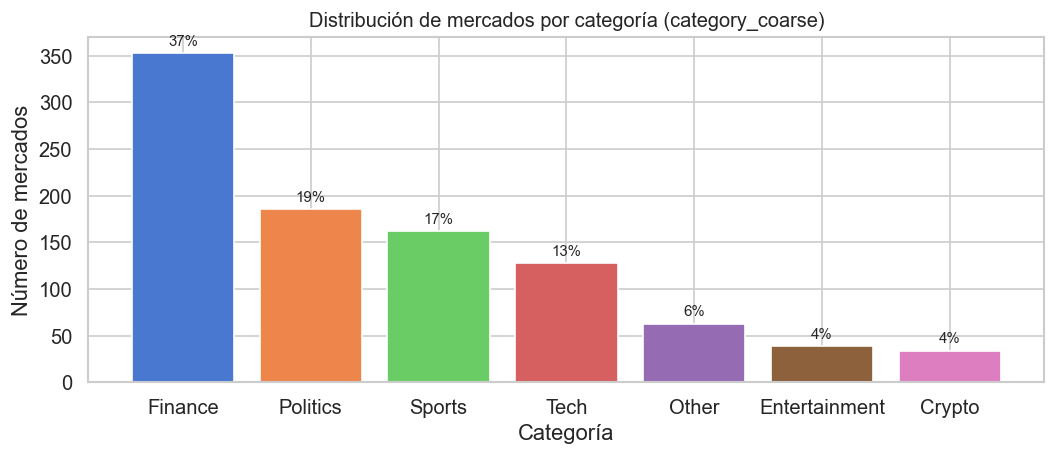

category_coarse
Finance          353
Politics         186
Sports           162
Tech             128
Other             63
Entertainment     39
Crypto            34


In [3]:
# Distribución de categorías
cat_counts = df['category_coarse'].value_counts()
cat_pct    = (cat_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cat_counts.index, cat_counts.values,
               color=sns.color_palette('muted', len(cat_counts)))
for bar, pct in zip(bars, cat_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{pct:.0f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Distribución de mercados por categoría (category_coarse)', fontsize=12)
ax.set_xlabel('Categoría')
ax.set_ylabel('Número de mercados')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cat_distribution.png')
plt.show()
print(cat_counts.to_string())

In [4]:
# Investigación del grupo Other — 30 ejemplos aleatorios
other_df = df[df['category_coarse'] == 'Other'][['question', 'event_ticker']].copy()
print(f'Total Other: {len(other_df)}  ({len(other_df)/len(df)*100:.1f}%)\n')
print('30 ejemplos aleatorios (seed=42):')
print('-' * 90)
for _, row in other_df.sample(min(30, len(other_df)), random_state=42).iterrows():
    print(f'  [{row["event_ticker"][:28]:28s}]  {row["question"][:80]}')

Total Other: 63  (6.5%)

30 ejemplos aleatorios (seed=42):
------------------------------------------------------------------------------------------
  [which-artists-will-have-1-hi]  Will Kanye West have a #1 hit in April?
  [precipitation-in-nyc-in-apri]  Will NYC have more than 6 inches of precipitation in April?
  [will-drake-release-iceman-by]  Will Drake officially release Iceman by April 30, 2026?
  [will-mara-corina-machado-ent]  Will María Corina Machado enter Venezuela by April 30?
  [precipitation-in-nyc-in-apri]  Will NYC have between 3 and 4 inches of precipitation in April?
  [precipitation-in-nyc-in-apri]  Will NYC have between 5 and 6 inches of precipitation in April?
  [which-artists-will-have-1-hi]  Will Olivia Dean have a #1 hit in April?
  [clavicular-arrested-again-by]  Clavicular arrested again by April 30?
  [will-dantes-receive-a-twitch]  Will Dantes receive a Twitch ban by May 1, 2026?
  [will-valve-will-add-cache-to]  Will Valve add Cache to the Map Pool by Ap

In [5]:
# Análisis de ticker prefixes en Other — ¿qué dominios son?
other_df = other_df.copy()
other_df['ticker_prefix'] = other_df['event_ticker'].str.split('-').str[0]
prefix_counts = other_df['ticker_prefix'].value_counts().head(20)
print('Top 20 ticker prefixes en Other:')
for p, c in prefix_counts.items():
    sample_q = other_df[other_df['ticker_prefix'] == p]['question'].iloc[0][:70]
    print(f'  {p:20s}  n={c:3d}  ej: {sample_q}')

Top 20 ticker prefixes en Other:
  will                  n= 14  ej: Will Drake officially release Iceman by April 30, 2026?
  precipitation         n= 13  ej: Will Seattle have between 3.5 and 4 inches of precipitation in April?
  which                 n=  8  ej: Will Olivia Dean have a #1 hit in April?
  measles               n=  4  ej: Will there be at least 2000 measles cases in the U.S. by April 30, 202
  us                    n=  4  ej: U.S. evacuates Beirut Embassy by April 30?
  how                   n=  2  ej: Will the DHS shutdown last 80 days or more?
  when                  n=  2  ej: Will the DHS shutdown end between April 25-28, 2026?
  clavicular            n=  2  ej: Clavicular arrested again by April 30?
  either                n=  2  ej: Will either Tate brother be arrested by March 31?
  2026                  n=  2  ej: Will León win Liga MX?
  major                 n=  1  ej: Major solar storm by April 30?
  uefa                  n=  1  ej: Will AEK Athens score the 

### 2.2  Refinamiento de categorías (si aplica)

Basado en los ejemplos arriba, evaluamos si `Other` es legítimamente miscelánea
o si hay patrones que deben capturarse con reglas adicionales.

In [6]:
# Clasificación manual de los grupos en Other
# Completar después de revisar los ejemplos arriba

# Top preguntas Other por event_ticker
other_df2 = df[df['category_coarse'] == 'Other'].copy()
other_df2['ticker_prefix'] = other_df2['event_ticker'].str.split('-').str[:2].str.join('-')

print('\nDistribución de 2-palabras de ticker en Other (top 25):')
tp2 = other_df2['ticker_prefix'].value_counts().head(25)
for p, c in tp2.items():
    pct = c / len(other_df2) * 100
    print(f'  {p:35s}  {c:3d} ({pct:.1f}%)')


Distribución de 2-palabras de ticker en Other (top 25):
  precipitation-in                      13 (20.6%)
  which-artists                          8 (12.7%)
  measles-cases                          4 (6.3%)
  how-long                               2 (3.2%)
  when-will                              2 (3.2%)
  us-evacuates                           2 (3.2%)
  will-mrbeast                           2 (3.2%)
  either-tate                            2 (3.2%)
  will-drake                             1 (1.6%)
  major-solar                            1 (1.6%)
  will-sofr                              1 (1.6%)
  uefa-europa                            1 (1.6%)
  clavicular-arrested                    1 (1.6%)
  us-anti                                1 (1.6%)
  will-epstein                           1 (1.6%)
  clavicular-banned                      1 (1.6%)
  will-clavicular                        1 (1.6%)
  will-dantes                            1 (1.6%)
  will-forsen                            

## 3. Distribución del target (YES/NO) por categoría

YES rate por categoría:
                 Total  YES   NO  YES_pct
category_coarse                          
Crypto              34   13   21     38.2
Finance            353   57  296     16.1
Entertainment       39    4   35     10.3
Tech               128   11  117      8.6
Sports             162   13  149      8.0
Politics           186   14  172      7.5
Other               63    3   60      4.8


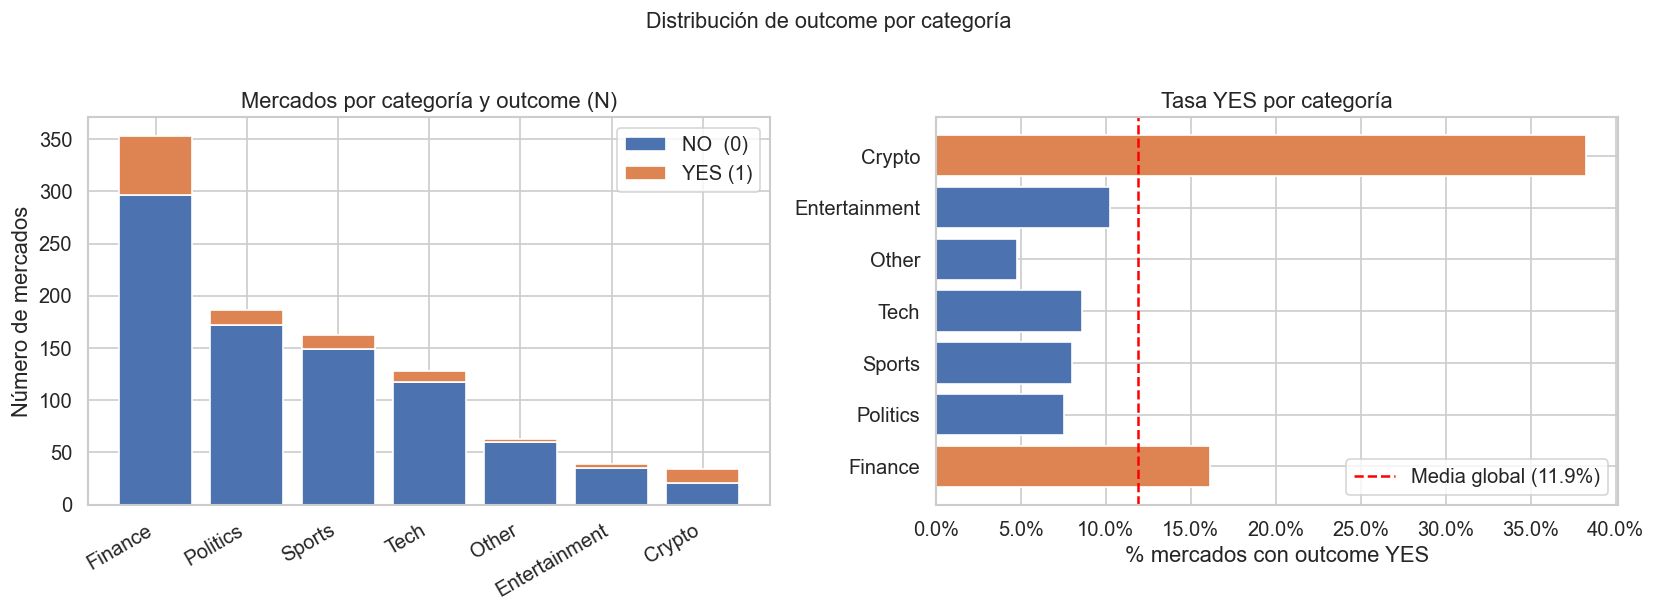

In [7]:
# YES rate por categoría
cat_outcome = (df.groupby('category_coarse')['outcome']
                 .agg(['sum', 'count', 'mean'])
                 .rename(columns={'sum': 'YES', 'count': 'Total', 'mean': 'YES_rate'})
                 .sort_values('YES_rate', ascending=False))
cat_outcome['NO']      = cat_outcome['Total'] - cat_outcome['YES']
cat_outcome['YES_pct'] = (cat_outcome['YES_rate'] * 100).round(1)

print('YES rate por categoría:')
print(cat_outcome[['Total', 'YES', 'NO', 'YES_pct']].to_string())

# Figura: stacked bar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: conteos absolutos
ax = axes[0]
cats_sorted = cat_outcome.sort_values('Total', ascending=False).index
no_vals  = cat_outcome.loc[cats_sorted, 'NO']
yes_vals = cat_outcome.loc[cats_sorted, 'YES']
x = range(len(cats_sorted))
ax.bar(x, no_vals.values,  label='NO  (0)', color='#4C72B0')
ax.bar(x, yes_vals.values, bottom=no_vals.values, label='YES (1)', color='#DD8452')
ax.set_xticks(list(x))
ax.set_xticklabels(cats_sorted, rotation=30, ha='right')
ax.set_title('Mercados por categoría y outcome (N)')
ax.set_ylabel('Número de mercados')
ax.legend()

# Derecha: tasa YES
ax2 = axes[1]
yes_rates = cat_outcome.loc[cats_sorted, 'YES_rate'] * 100
colors = ['#DD8452' if v > 12 else '#4C72B0' for v in yes_rates]
ax2.barh(range(len(cats_sorted)), yes_rates, color=colors)
ax2.axvline(df['outcome'].mean() * 100, color='red', linestyle='--', linewidth=1.5,
            label=f'Media global ({df["outcome"].mean()*100:.1f}%)')
ax2.set_yticks(range(len(cats_sorted)))
ax2.set_yticklabels(cats_sorted)
ax2.set_xlabel('% mercados con outcome YES')
ax2.set_title('Tasa YES por categoría')
ax2.xaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend()

plt.suptitle('Distribución de outcome por categoría', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'target_by_category.png', bbox_inches='tight')
plt.show()

## 4. Análisis de features de precio

### 4.1  Estadísticas descriptivas

In [8]:
PRICE_FEATURES = [
    'precio_inicio', 'precio_fin', 'precio_media', 'precio_mediana',
    'precio_std', 'precio_rango', 'precio_tendencia', 'volatilidad_retornos'
]
DAY_COLS = [f'precio_dia_{d}' for d in range(1, 8)]

print('Estadísticas descriptivas — features de precio:')
df[PRICE_FEATURES].describe().round(4)

Estadísticas descriptivas — features de precio:


,precio_inicio,precio_fin,precio_media,precio_mediana,precio_std,precio_rango,precio_tendencia,volatilidad_retornos
count,965.0000,965.0000,965.0000,965.0000,965.0000,965.0000,965.0000,965.0000
mean,0.4031,0.2906,0.3260,0.3161,0.0858,0.2066,-0.0224,0.4433
std,0.1617,0.2397,0.1930,0.2099,0.0660,0.1487,0.0451,0.4585
min,0.0015,0.0005,0.0015,0.0015,0.0000,0.0000,-0.2412,0.0000
25%,0.3100,0.0650,0.1525,0.1125,0.0268,0.0670,-0.0441,0.0915
50%,0.4800,0.2500,0.3167,0.3100,0.0745,0.1940,-0.0138,0.2774
75%,0.5000,0.4850,0.4800,0.4950,0.1324,0.3260,-0.0000,0.6554
max,0.9605,0.9820,0.9629,0.9670,0.3520,0.7600,0.2000,2.5778


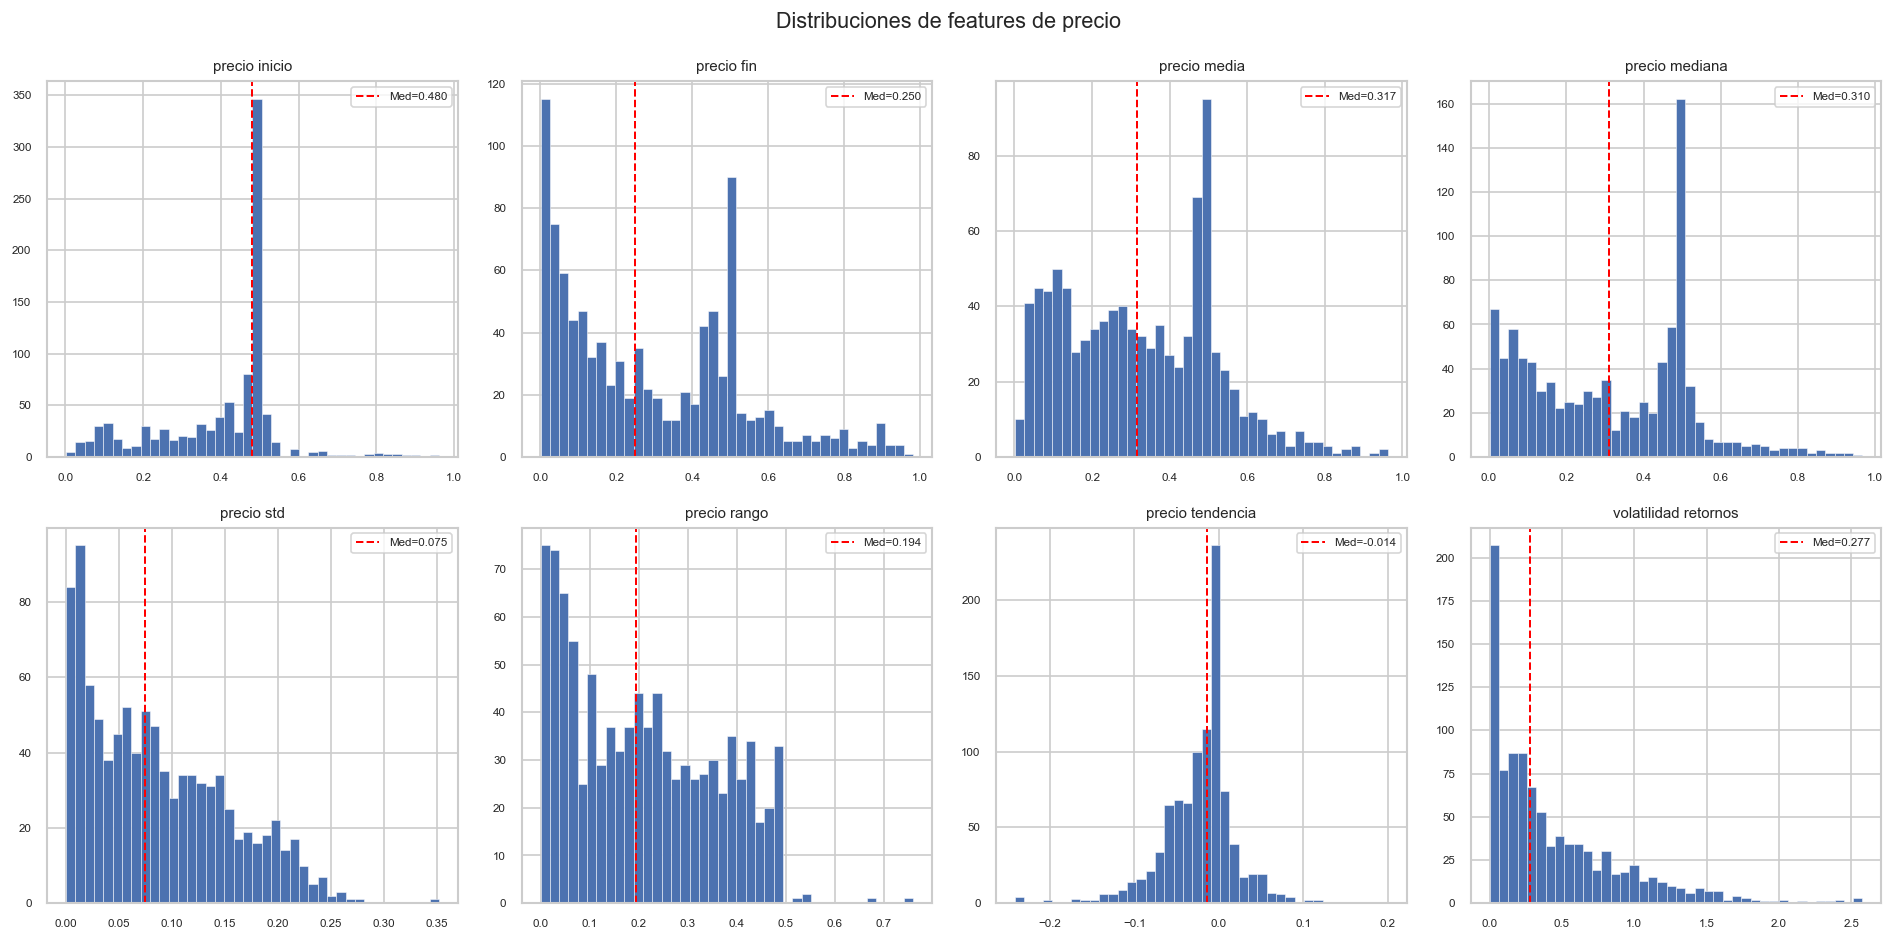

In [9]:
# Distribuciones de cada feature de precio
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(PRICE_FEATURES):
    ax = axes[i]
    data = df[feat].dropna()
    ax.hist(data, bins=40, color='#4C72B0', edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.2,
               label=f'Med={data.median():.3f}')
    ax.set_title(feat.replace('_', ' '), fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle('Distribuciones de features de precio', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'price_features_distributions.png')
plt.show()

### 4.2  Separación por outcome (YES vs NO)

¿Las distribuciones de precio difieren entre mercados que terminan YES vs NO?

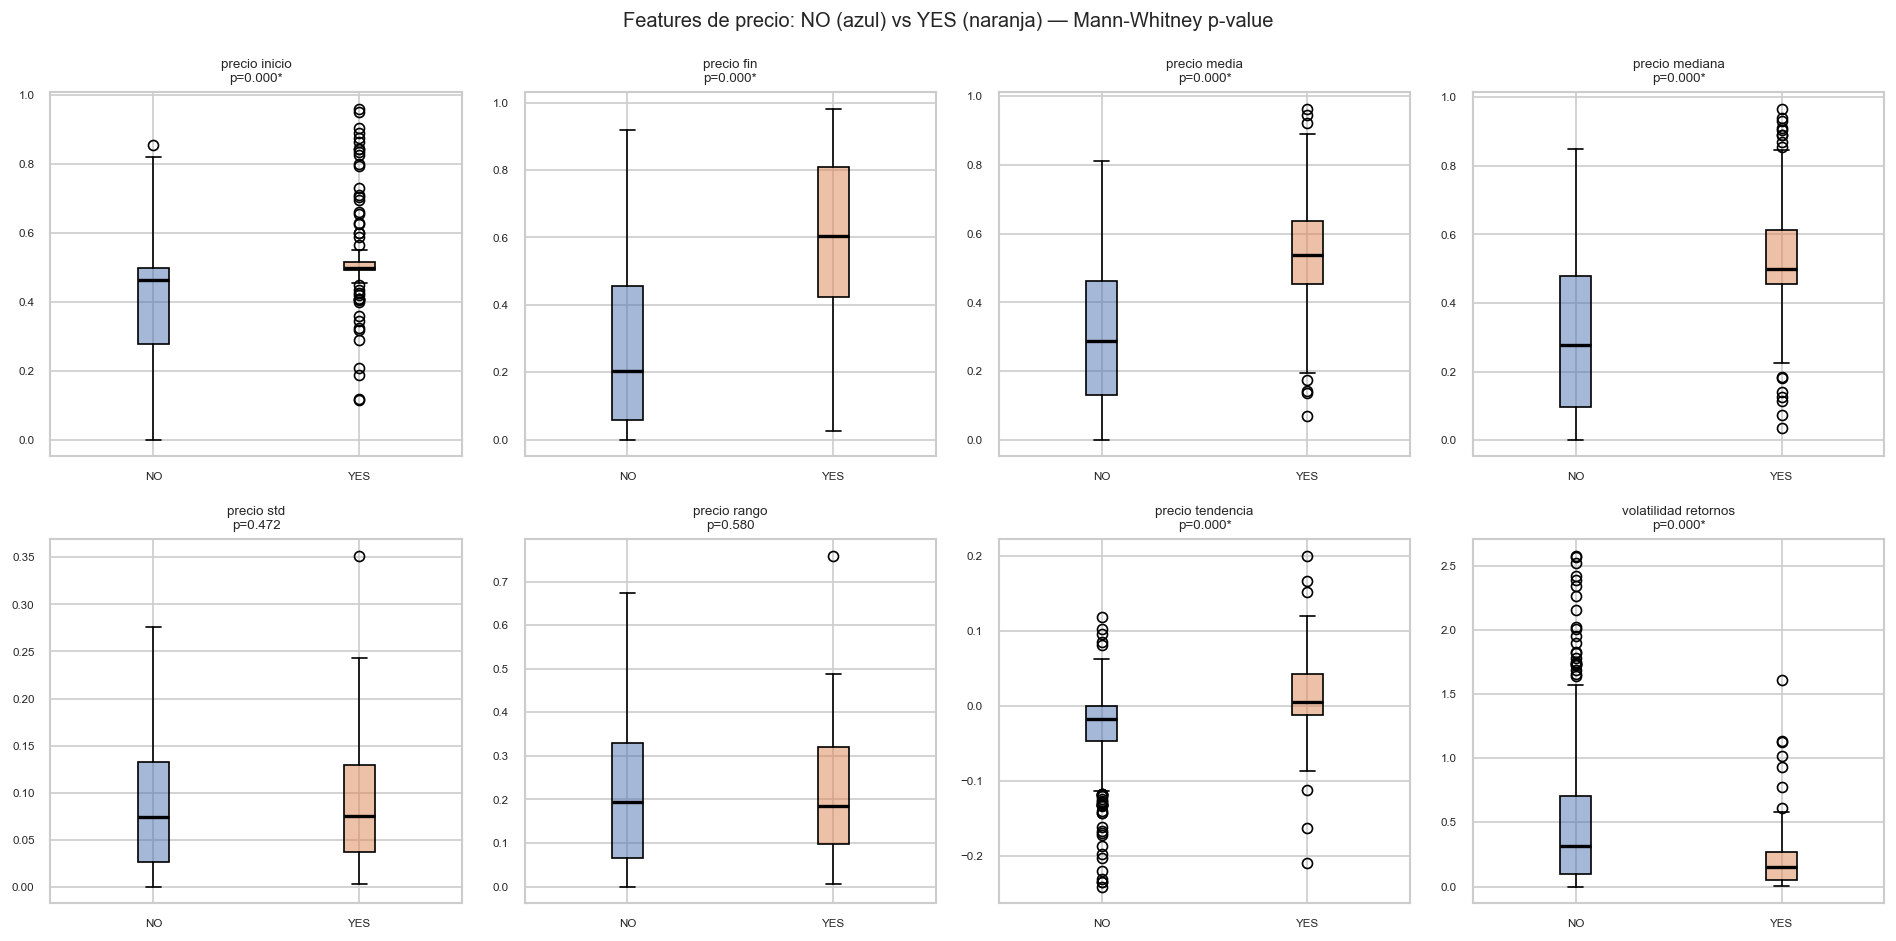

In [10]:
# Boxplots por outcome
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(PRICE_FEATURES):
    ax = axes[i]
    data_no  = df.loc[df.outcome == 0, feat].dropna()
    data_yes = df.loc[df.outcome == 1, feat].dropna()
    bp = ax.boxplot([data_no, data_yes], labels=['NO', 'YES'],
                    patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#4C72B080')
    bp['boxes'][1].set_facecolor('#DD845280')

    # Test Mann-Whitney U
    stat, p = stats.mannwhitneyu(data_no, data_yes, alternative='two-sided')
    ax.set_title(f"{feat.replace('_', ' ')}\np={p:.3f}{'*' if p < 0.05 else ''}",
                 fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Features de precio: NO (azul) vs YES (naranja) — Mann-Whitney p-value',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'price_features_by_outcome.png')
plt.show()

### 4.3  Correlación entre features y con el outcome

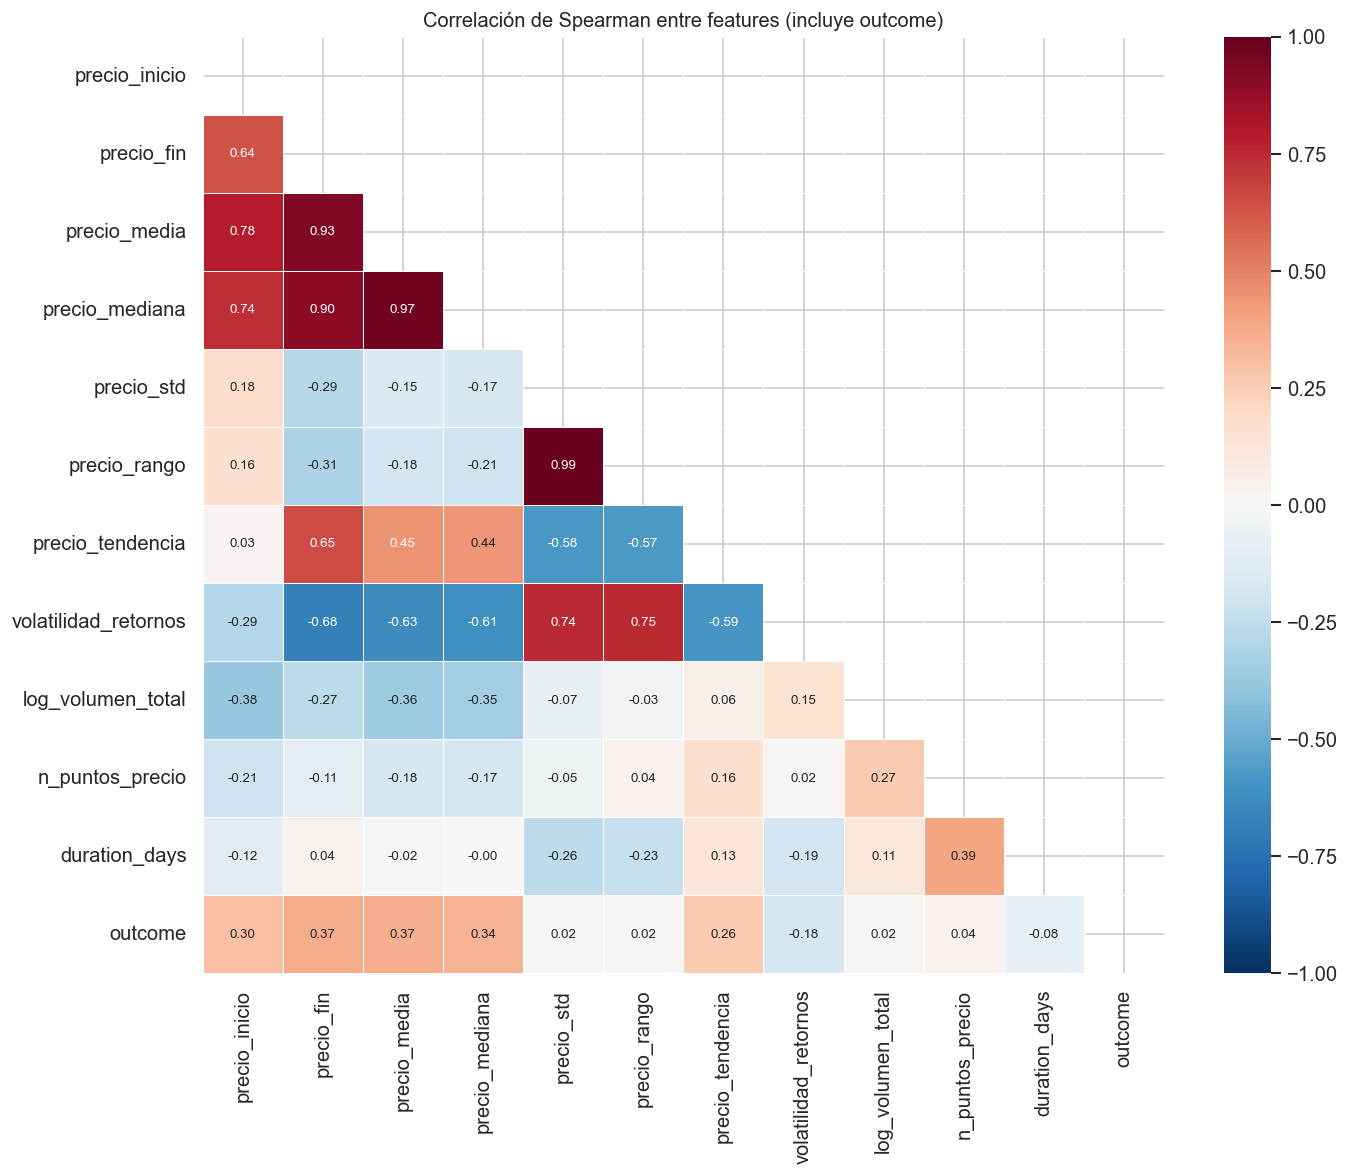

In [11]:
# Matriz de correlación (Spearman, más robusta a outliers que Pearson)
corr_cols = PRICE_FEATURES + ['log_volumen_total', 'n_puntos_precio', 'duration_days', 'outcome']
corr_matrix = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlación de Spearman entre features (incluye outcome)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'price_correlation_matrix.png', bbox_inches='tight')
plt.show()

Correlación con outcome (YES=1):
                      r_pointbiserial    p_pb  rho_spearman    p_sp
feature                                                            
precio_fin                     0.4411  0.0000        0.3696  0.0000
precio_media                   0.4022  0.0000        0.3660  0.0000
precio_mediana                 0.3658  0.0000        0.3443  0.0000
precio_inicio                  0.2841  0.0000        0.2988  0.0000
precio_tendencia               0.2652  0.0000        0.2643  0.0000
n_puntos_precio                0.0251  0.4360        0.0425  0.1867
precio_std                     0.0220  0.4952        0.0232  0.4723
log_volumen_total              0.0220  0.4952        0.0180  0.5760
precio_rango                   0.0134  0.6773        0.0178  0.5801
duration_days                 -0.0613  0.0568       -0.0793  0.0138
volatilidad_retornos          -0.1732  0.0000       -0.1762  0.0000


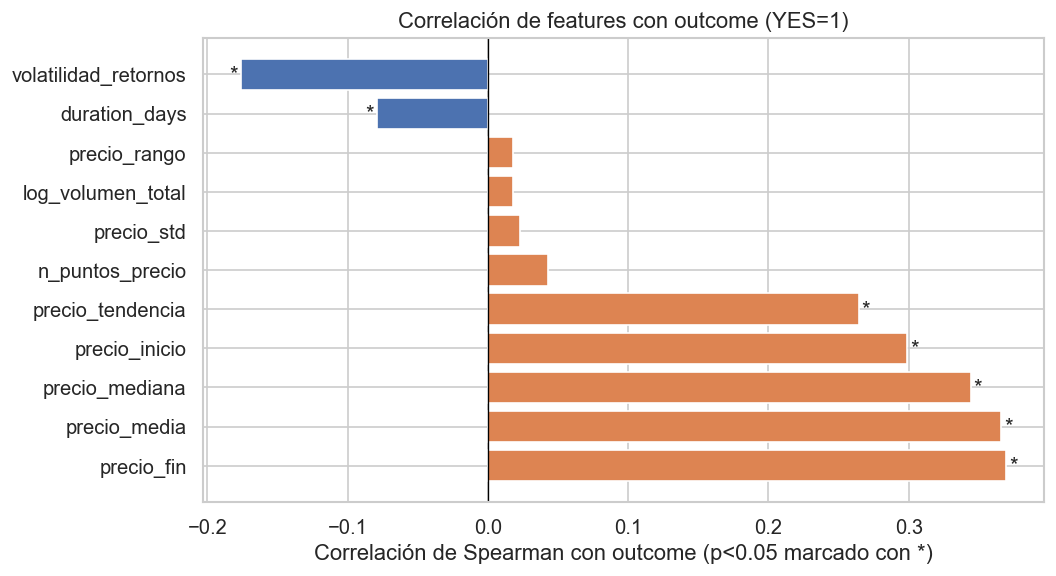

In [12]:
# Correlación de cada feature con outcome (Spearman + point-biserial)
from scipy.stats import pointbiserialr, spearmanr

num_feats = PRICE_FEATURES + ['log_volumen_total', 'n_puntos_precio', 'duration_days']
results = []
for feat in num_feats:
    valid = df[[feat, 'outcome']].dropna()
    r_pb, p_pb = pointbiserialr(valid['outcome'], valid[feat])
    r_sp, p_sp = spearmanr(valid[feat], valid['outcome'])
    results.append({'feature': feat, 'r_pointbiserial': r_pb, 'p_pb': p_pb,
                    'rho_spearman': r_sp, 'p_sp': p_sp})

corr_df = pd.DataFrame(results).set_index('feature').sort_values('rho_spearman', ascending=False)
print('Correlación con outcome (YES=1):')
print(corr_df.round(4).to_string())

# Figura: bar chart de correlaciones
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_df['rho_spearman']]
ax.barh(corr_df.index, corr_df['rho_spearman'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
sig = corr_df['p_sp'] < 0.05
for i, (feat, row_) in enumerate(corr_df.iterrows()):
    if sig[feat]:
        ax.text(row_['rho_spearman'] + 0.002 * (1 if row_['rho_spearman'] >= 0 else -1),
                i, '*', ha='left' if row_['rho_spearman'] >= 0 else 'right', va='center')
ax.set_xlabel('Correlación de Spearman con outcome (p<0.05 marcado con *)')
ax.set_title('Correlación de features con outcome (YES=1)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_outcome_correlation.png')
plt.show()

## 5. Análisis temporal

### 5.1  Distribución de mercados por mes

23:41:30  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:41:30  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:41:30  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:41:30  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


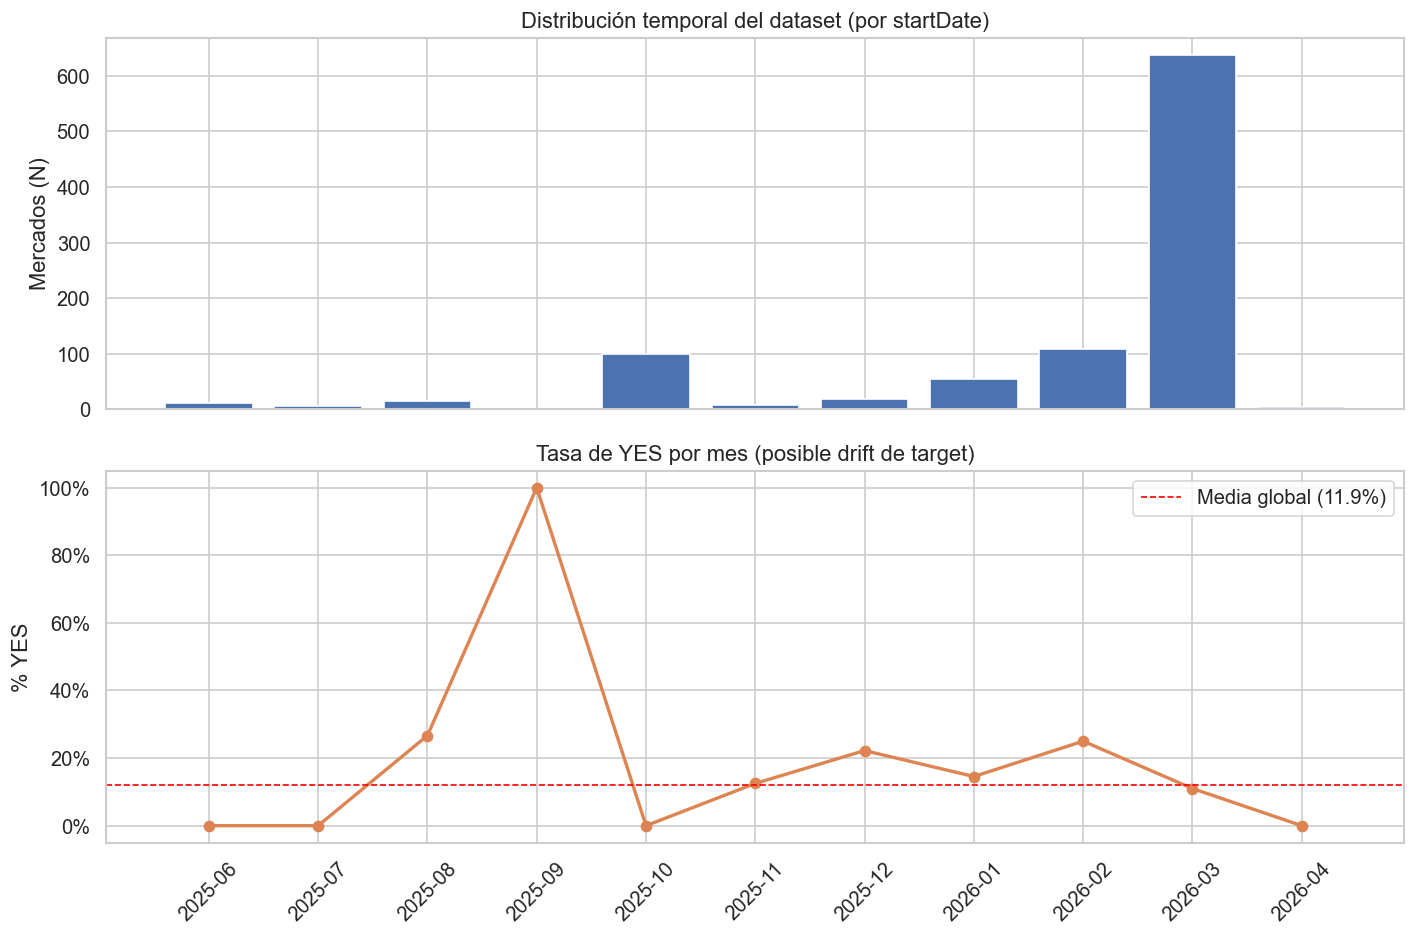


Resumen por mes:
start_month  total  yes  yes_rate
    2025-06     12    0  0.000000
    2025-07      7    0  0.000000
    2025-08     15    4  0.266667
    2025-09      1    1  1.000000
    2025-10    100    0  0.000000
    2025-11      8    1  0.125000
    2025-12     18    4  0.222222
    2026-01     55    8  0.145455
    2026-02    108   27  0.250000
    2026-03    637   70  0.109890
    2026-04      4    0  0.000000


In [13]:
df['start_month'] = df['start_date'].dt.to_period('M')
df['closed_month'] = df['closed_date'].dt.to_period('M')
df['start_quarter'] = df['start_date'].dt.to_period('Q')

monthly_counts = df.groupby('start_month').agg(
    total=('outcome', 'count'),
    yes=('outcome', 'sum')
).reset_index()
monthly_counts['yes_rate'] = monthly_counts['yes'] / monthly_counts['total']

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Conteo de mercados
ax = axes[0]
x_labels = monthly_counts['start_month'].astype(str)
ax.bar(x_labels, monthly_counts['total'], color='#4C72B0')
ax.set_ylabel('Mercados (N)')
ax.set_title('Distribución temporal del dataset (por startDate)')
ax.tick_params(axis='x', rotation=45)

# Tasa YES
ax2 = axes[1]
ax2.plot(x_labels, monthly_counts['yes_rate'] * 100, 'o-', color='#DD8452', linewidth=2)
ax2.axhline(df['outcome'].mean() * 100, color='red', linestyle='--', linewidth=1,
            label=f'Media global ({df["outcome"].mean()*100:.1f}%)')
ax2.set_ylabel('% YES')
ax2.set_title('Tasa de YES por mes (posible drift de target)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'temporal_distribution.png')
plt.show()

print('\nResumen por mes:')
print(monthly_counts.to_string(index=False))

23:41:31  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:41:31  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:41:31  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:41:31  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:41:31  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:41:31  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:41:31  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


23:41:31  INFO      Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


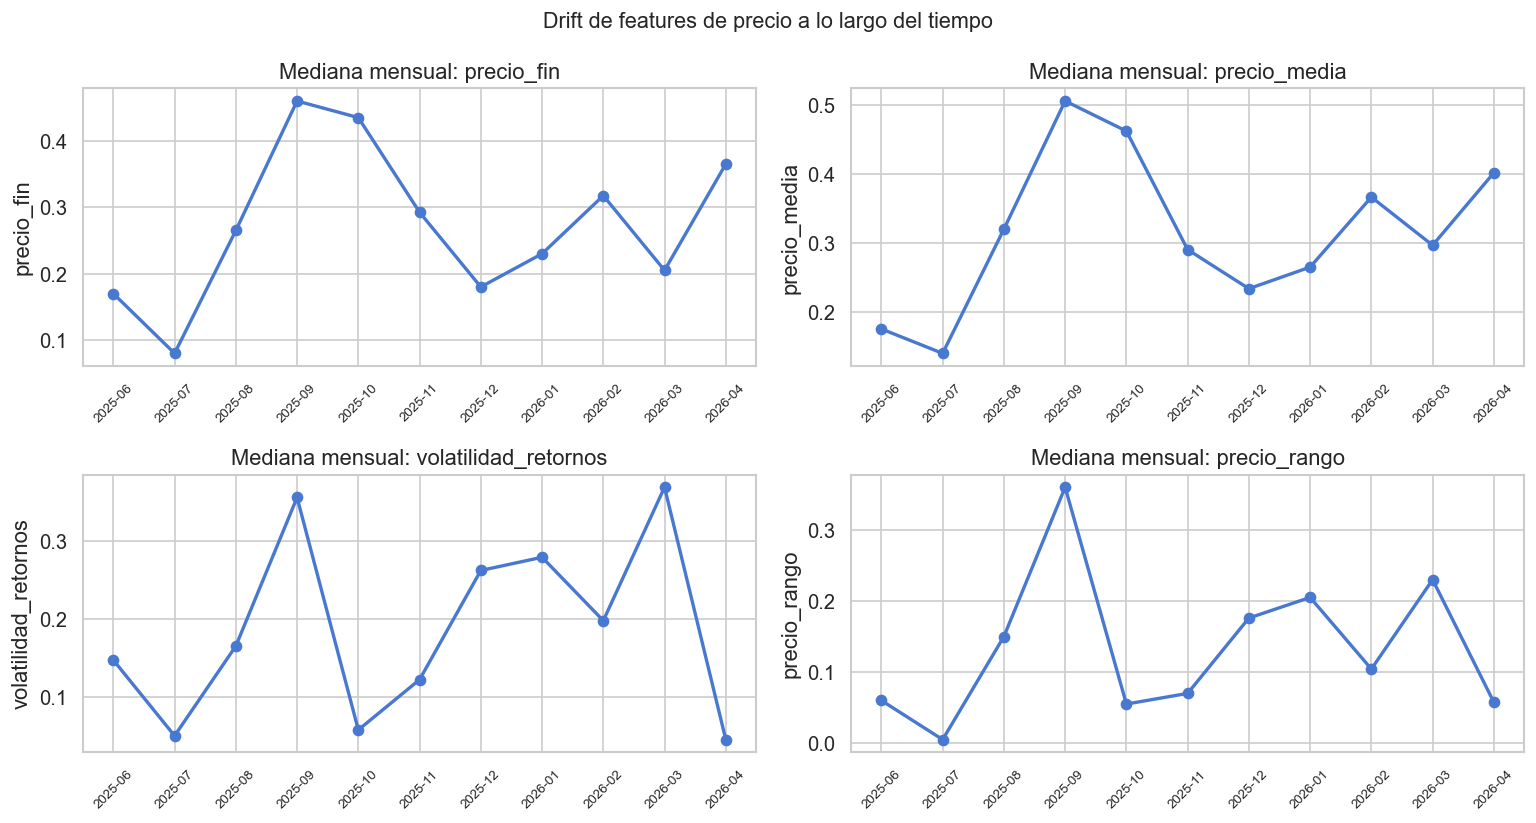

In [14]:
# Drift de features de precio por mes
feat_drift = df.groupby('start_month')[['precio_fin', 'precio_media', 'volatilidad_retornos', 'precio_rango']].median()

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()
feats_to_plot = ['precio_fin', 'precio_media', 'volatilidad_retornos', 'precio_rango']

for i, feat in enumerate(feats_to_plot):
    ax = axes[i]
    x = feat_drift.index.astype(str)
    ax.plot(x, feat_drift[feat], 'o-', linewidth=2)
    ax.set_title(f'Mediana mensual: {feat}')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_ylabel(feat)

plt.suptitle('Drift de features de precio a lo largo del tiempo', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_drift.png')
plt.show()

## 6. Features adicionales

### 6.1  `n_puntos_precio`

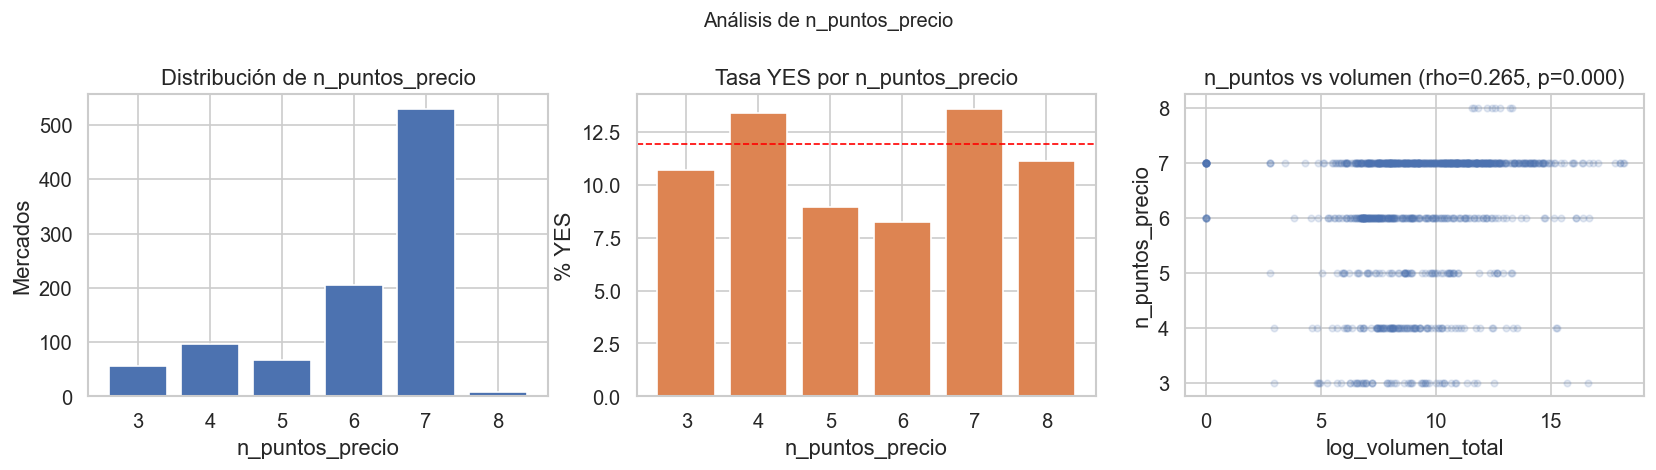

In [15]:
# n_puntos_precio: distribución, relación con outcome y volumen
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribución
ax = axes[0]
npts_counts = df['n_puntos_precio'].value_counts().sort_index()
ax.bar(npts_counts.index, npts_counts.values, color='#4C72B0')
ax.set_xlabel('n_puntos_precio')
ax.set_ylabel('Mercados')
ax.set_title('Distribución de n_puntos_precio')

# YES rate por n_puntos
ax2 = axes[1]
npts_yes = df.groupby('n_puntos_precio')['outcome'].mean() * 100
npts_n   = df.groupby('n_puntos_precio')['outcome'].count()
ax2.bar(npts_yes.index, npts_yes.values, color='#DD8452')
ax2.axhline(df['outcome'].mean() * 100, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel('n_puntos_precio')
ax2.set_ylabel('% YES')
ax2.set_title('Tasa YES por n_puntos_precio')

# Correlación con log_volumen
ax3 = axes[2]
ax3.scatter(df['log_volumen_total'], df['n_puntos_precio'], alpha=0.15, s=15, color='#4C72B0')
r, p = stats.spearmanr(df['log_volumen_total'], df['n_puntos_precio'])
ax3.set_xlabel('log_volumen_total')
ax3.set_ylabel('n_puntos_precio')
ax3.set_title(f'n_puntos vs volumen (rho={r:.3f}, p={p:.3f})')

plt.suptitle('Análisis de n_puntos_precio', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'n_puntos_analysis.png')
plt.show()

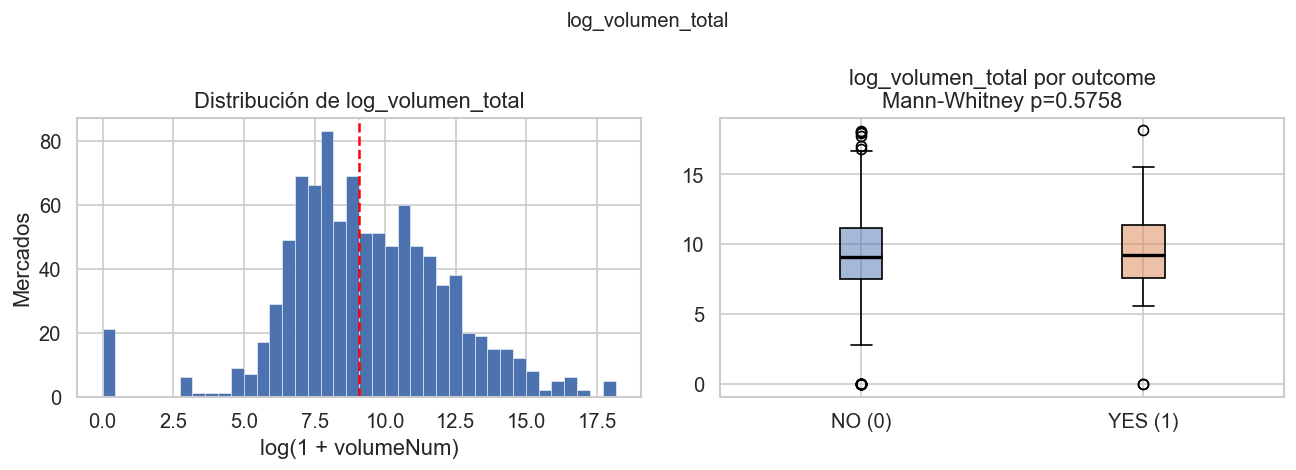

Mercados con volumen=0: 21
Percentiles de volumen:
count    965.000
mean       9.335
std        2.932
min        0.000
5%         5.558
25%        7.501
50%        9.062
75%       11.200
95%       14.216
max       18.158
Name: log_volumen_total, dtype: float64


In [16]:
# log_volumen_total: distribución y relación con outcome
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.hist(df['log_volumen_total'], bins=40, color='#4C72B0', edgecolor='white', linewidth=0.3)
ax.axvline(df['log_volumen_total'].median(), color='red', linestyle='--')
ax.set_xlabel('log(1 + volumeNum)')
ax.set_ylabel('Mercados')
ax.set_title('Distribución de log_volumen_total')

ax2 = axes[1]
data_no  = df.loc[df.outcome == 0, 'log_volumen_total']
data_yes = df.loc[df.outcome == 1, 'log_volumen_total']
bp = ax2.boxplot([data_no, data_yes], labels=['NO (0)', 'YES (1)'],
                 patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#4C72B080')
bp['boxes'][1].set_facecolor('#DD845280')
stat, p = stats.mannwhitneyu(data_no, data_yes, alternative='two-sided')
ax2.set_title(f'log_volumen_total por outcome\nMann-Whitney p={p:.4f}')

plt.suptitle('log_volumen_total', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'volumen_analysis.png')
plt.show()

print('Mercados con volumen=0:', (df['log_volumen_total'] == 0).sum())
print('Percentiles de volumen:')
print(df['log_volumen_total'].describe(percentiles=[.05, .25, .5, .75, .95]).round(3))

In [17]:
# Detección de outliers — rango intercuartílico para features numéricas
num_cols = PRICE_FEATURES + ['log_volumen_total', 'duration_days']
outlier_summary = []
for col in num_cols:
    d = df[col].dropna()
    q1, q3 = d.quantile([0.25, 0.75])
    iqr  = q3 - q1
    low  = q1 - 3 * iqr
    high = q3 + 3 * iqr
    n_out = ((d < low) | (d > high)).sum()
    outlier_summary.append({'feature': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
                             'low_fence': low, 'high_fence': high, 'n_outliers_3IQR': n_out})

out_df = pd.DataFrame(outlier_summary).set_index('feature')
print('Outliers extremos (±3 IQR):')
print(out_df[['Q1', 'Q3', 'n_outliers_3IQR']].round(4).to_string())

Outliers extremos (±3 IQR):
                           Q1       Q3  n_outliers_3IQR
feature                                                
precio_inicio          0.3100   0.5000                0
precio_fin             0.0650   0.4850                0
precio_media           0.1525   0.4800                0
precio_mediana         0.1125   0.4950                0
precio_std             0.0268   0.1324                0
precio_rango           0.0670   0.3260                0
precio_tendencia      -0.0441  -0.0000               12
volatilidad_retornos   0.0915   0.6554                5
log_volumen_total      7.5009  11.2003                0
duration_days         37.0000  83.0000               35


In [18]:
# Casos extremos en las 3 features con más outliers
for feat in out_df.nlargest(3, 'n_outliers_3IQR').index:
    d   = df[feat].dropna()
    q1, q3 = d.quantile([0.25, 0.75])
    iqr = q3 - q1
    extreme = df[np.abs(df[feat] - d.median()) > 3 * iqr][['question', feat, 'outcome', 'log_volumen_total']]
    print(f'\n--- {feat} (extremos) ---')
    print(extreme.sort_values(feat, ascending=False).head(5).to_string())


--- duration_days (extremos) ---
                                                   question  duration_days  outcome  log_volumen_total
72         Will the Boston Celtics win the 2026 NBA Finals?            313        0          16.408468
960     Will the Utah Mammoth win the 2026 NHL Stanley Cup?            312        0          14.182145
588       Will the Houston Rockets win the 2026 NBA Finals?            312        0          15.978615
491    Will the Boston Bruins win the 2026 NHL Stanley Cup?            312        0          14.243290
270  Will the Edmonton Oilers win the 2026 NHL Stanley Cup?            311        0          13.695595

--- precio_tendencia (extremos) ---
                                                                                                       question  precio_tendencia  outcome  log_volumen_total
867                       Will Project Hail Mary be the March film with the highest domestic gross on April 30?          0.200000        1          10.82

## 7. Clustering exploratorio (k-means)

K-means sobre el perfil de precios diarios (días 1–7) para identificar
tipos de mercados según su trayectoria de precio.

Mercados con los 7 días completos: 539 (55.9%)


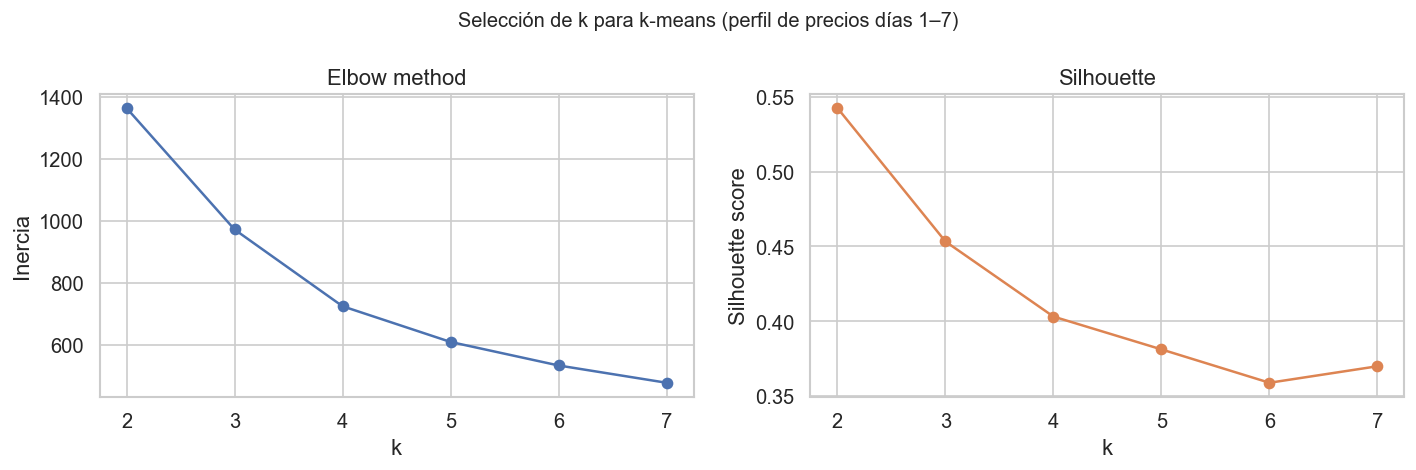


Silhouette scores:
  k=2: 0.5424
  k=3: 0.4533
  k=4: 0.4032
  k=5: 0.3813
  k=6: 0.3590
  k=7: 0.3700


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Usamos sólo mercados con los 7 puntos completos para el clustering principal
df_clust = df[DAY_COLS].dropna()
idx_clust = df_clust.index
print(f'Mercados con los 7 días completos: {len(df_clust)} ({len(df_clust)/len(df)*100:.1f}%)')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# Elbow + Silhouette para k = 2..7
inertias   = []
silhouettes = []
K_RANGE = range(2, 8)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#4C72B0')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia'); axes[0].set_title('Elbow method')
axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='#DD8452')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette score'); axes[1].set_title('Silhouette')
plt.suptitle('Selección de k para k-means (perfil de precios días 1–7)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'clustering_elbow_silhouette.png')
plt.show()

print('\nSilhouette scores:')
for k, s in zip(K_RANGE, silhouettes):
    print(f'  k={k}: {s:.4f}')

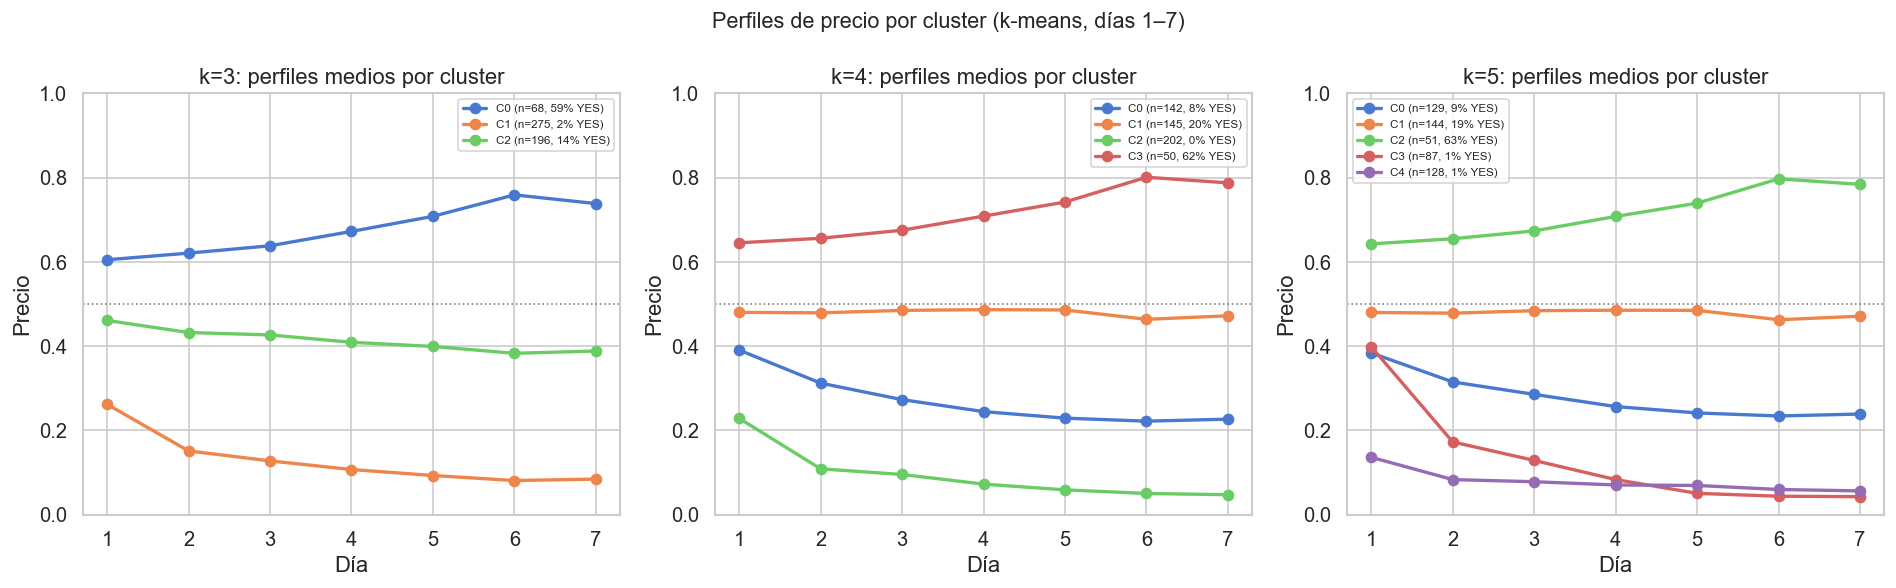

In [20]:
# Ajustar con k=3, k=4 y k=5 y visualizar perfiles medios
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
days = list(range(1, 8))
BEST_K = None  # se determina abajo

for ax_i, k in enumerate([3, 4, 5]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    cluster_means = scaler.inverse_transform(km.cluster_centers_)

    ax = axes[ax_i]
    for c in range(k):
        n_c = (labels == c).sum()
        yes_rate = df.loc[idx_clust, 'outcome'][labels == c].mean() * 100
        ax.plot(days, cluster_means[c], 'o-', linewidth=2,
                label=f'C{c} (n={n_c}, {yes_rate:.0f}% YES)')
    ax.set_xlabel('Día'); ax.set_ylabel('Precio')
    ax.set_title(f'k={k}: perfiles medios por cluster')
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='grey', linestyle=':', linewidth=1)

plt.suptitle('Perfiles de precio por cluster (k-means, días 1–7)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'clustering_profiles.png')
plt.show()

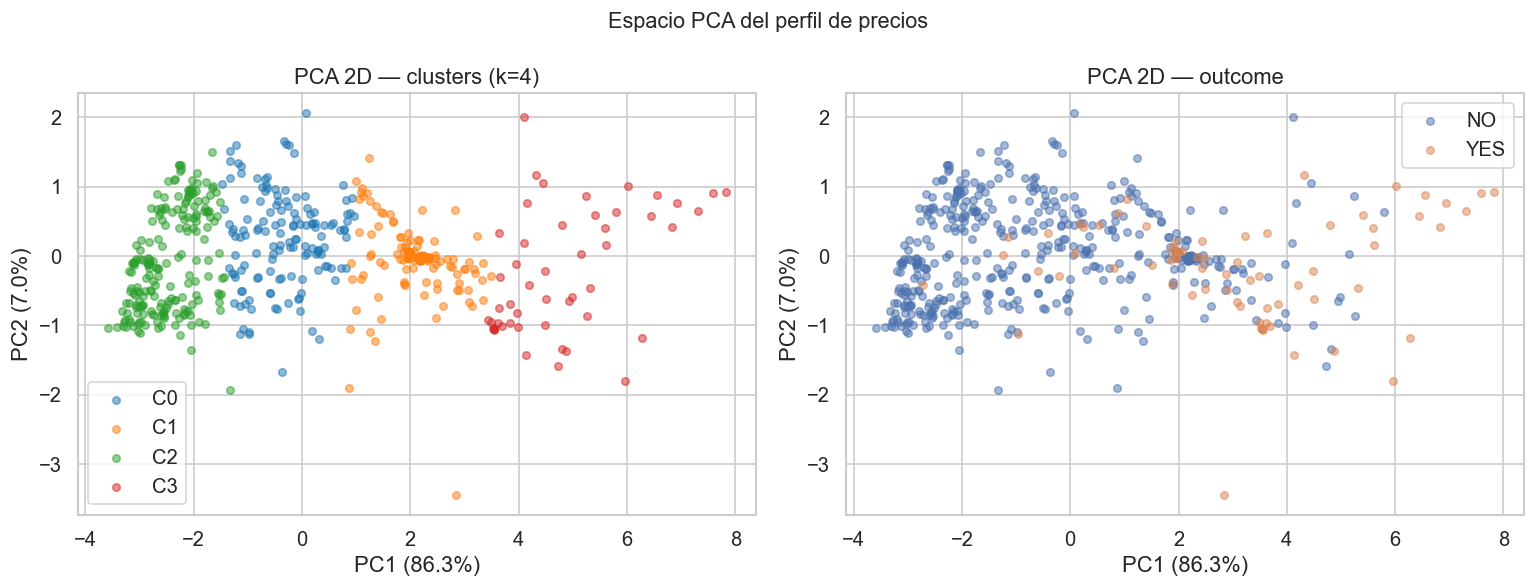


Tabla: cluster × outcome
          NO  YES  Total  YES_rate%
cluster                            
0        130   12    142        8.5
1        116   29    145       20.0
2        201    1    202        0.5
3         19   31     50       62.0
All      466   73    539       13.5


In [21]:
# Cluster elegido (ajustar BEST_K según elbow+silhouette)
BEST_K = 4  # ajustar después de ver elbow y silhouette

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df.loc[idx_clust, 'cluster'] = km_final.fit_predict(X_scaled).astype(str)

# PCA 2D para visualización
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
labels_final = km_final.labels_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = sns.color_palette('tab10', BEST_K)

# Por cluster
ax = axes[0]
for c in range(BEST_K):
    mask = labels_final == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=20, alpha=0.5,
               color=palette[c], label=f'C{c}')
ax.set_title(f'PCA 2D — clusters (k={BEST_K})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()

# Por outcome
ax2 = axes[1]
outcomes_clust = df.loc[idx_clust, 'outcome'].values
for o, label, color in [(0, 'NO', '#4C72B0'), (1, 'YES', '#DD8452')]:
    mask = outcomes_clust == o
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], s=20, alpha=0.5,
                color=color, label=label)
ax2.set_title('PCA 2D — outcome')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.legend()

plt.suptitle('Espacio PCA del perfil de precios', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'clustering_pca.png')
plt.show()

# Tabla: cluster × outcome
print('\nTabla: cluster × outcome')
df_clust_analysis = df.loc[idx_clust].copy()
df_clust_analysis['cluster'] = labels_final
ct = pd.crosstab(df_clust_analysis['cluster'], df_clust_analysis['outcome'],
                 margins=True)
ct.columns = ['NO', 'YES', 'Total']
ct['YES_rate%'] = (ct['YES'] / ct['Total'] * 100).round(1)
print(ct)

## 8. Resumen de hallazgos del EDA

> Completar después de revisar los resultados de las celdas anteriores.

In [22]:
# Guardar el DataFrame procesado para usar en Fase 4
df.to_parquet('../data/interim/eda_dataset.parquet', index=False)
print(f'DataFrame guardado: data/interim/eda_dataset.parquet  ({len(df)} filas, {df.shape[1]} cols)')

# Resumen numérico rápido
print(f'\n--- RESUMEN EDA ---')
print(f'Dataset: {len(df)} mercados')
print(f'Balance: YES={df.outcome.sum()} ({df.outcome.mean()*100:.1f}%)  NO={(~df.outcome.astype(bool)).sum()}')
print(f'Periodo: {df.start_date.min().date()} → {df.start_date.max().date()}')
print(f'n_puntos mediana: {df.n_puntos_precio.median()}  (55% con 7 puntos completos)')
print(f'precio_fin mediana: {df.precio_fin.median():.3f}')
print(f'volatilidad mediana: {df.volatilidad_retornos.median():.4f}')
print(f'log_vol mediana: {df.log_volumen_total.median():.2f}')
print(f'duration mediana: {df.duration_days.median():.0f} días')

DataFrame guardado: data/interim/eda_dataset.parquet  (965 filas, 29 cols)

--- RESUMEN EDA ---
Dataset: 965 mercados
Balance: YES=115 (11.9%)  NO=850
Periodo: 2025-06-23 → 2026-04-02
n_puntos mediana: 7.0  (55% con 7 puntos completos)
precio_fin mediana: 0.250
volatilidad mediana: 0.2774
log_vol mediana: 9.06
duration mediana: 42 días
